## Project_DAMI_042_044_046

<table align="left">
    <tr>
        <td style="text-align:left">Kode Mata Kuliah</td>
        <td style="text-align:left">:</td>
        <td style="text-align:left">12S3205</td>
    </tr>
    <tr>
        <td style="text-align:left">Nama Mata Kuliah</td>
        <td style="text-align:left">:</td>
        <td style="text-align:left">Data Mining</td>
    </tr>
    <tr>
        <td style="text-align:left">Topik</td>
        <td style="text-align:left">:</td>
        <td style="text-align:left"><i>Case 3: House Prices - Advanced Regression
Techniques</i></td>
    </tr>
</table>

# Import Libraries

In [6]:
import pandas as pd
import numpy as np
import os

from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load Datasets

In [7]:
for dirname, _, filenames in os.walk('./house_prices'):
    for filename in filenames:
        print(filename)

In [13]:
df_train = pd.read_csv('/content/sample_data/train.csv')
print(df_train.shape)

(1460, 81)


In [14]:
df_test = pd.read_csv('/content/sample_data/test.csv')
print(df_test.shape)

(1459, 80)


# Visualizing the Datasets

In [15]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [17]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [18]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

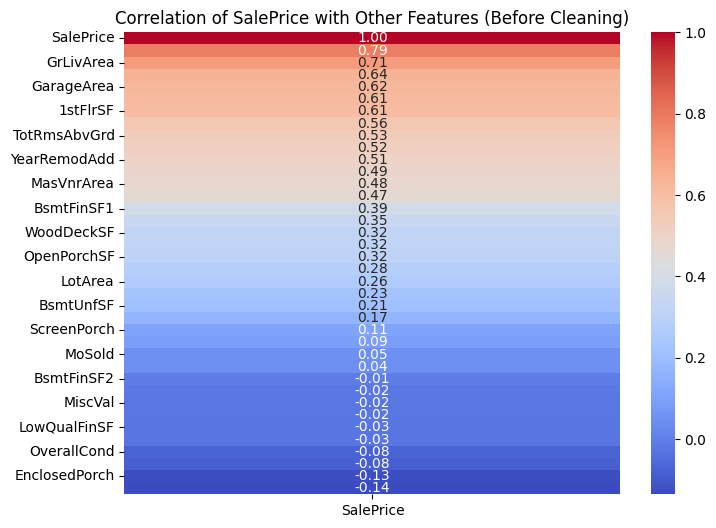

In [19]:
# Sebelum data di-cleaning
# Seleksi kolom numerik
numeric_df_raw = df_train.select_dtypes(include=['float64', 'int64'])

# Hitung matriks korelasi
corr_matrix_raw = numeric_df_raw.corr()

# Visualisasi korelasi SalePrice dengan fitur lainnya
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_raw[['SalePrice']].sort_values(by='SalePrice', ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('Correlation of SalePrice with Other Features (Before Cleaning)')
plt.show()


# Clean Data

In [20]:
# Find columns with missing values and calculate their counts and percentages
miss_val = df_train.isnull().sum()
miss_val = miss_val[miss_val > 0].sort_values(ascending=False)  # Filter only columns with missing values

# Create a DataFrame to display missing value counts and percentages
miss_val_df = pd.DataFrame({
    'MissingCount': miss_val,
    'Percent': (miss_val / df_test.shape[0] * 100).round(2)  # Calculate percentage and round to 2 decimals
})

miss_val_df


,MissingCount,Percent
PoolQC,1453,99.59
MiscFeature,1406,96.37
Alley,1369,93.83
Fence,1179,80.81
MasVnrType,872,59.77
FireplaceQu,690,47.29
LotFrontage,259,17.75
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [21]:
print(df_train.columns)


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [22]:
# drop columns with high missing values
df_train = df_train.drop(['Fence', 'MiscFeature', 'PoolQC','FireplaceQu','Alley'], axis=1)

In [23]:
# drop rows with any missing values
df_train.dropna(inplace=True)

In [24]:
# Check the dimension of the dataset
df_train.shape

(455, 76)

In [25]:
# Find columns with missing values and calculate their counts and percentages
miss_val = df_test.isnull().sum()
miss_val = miss_val[miss_val > 0].sort_values(ascending=False)  # Filter only columns with missing values

# Create a DataFrame to display missing value counts and percentages
miss_val_df = pd.DataFrame({
    'MissingCount': miss_val,
    'Percent': (miss_val / df_test.shape[0] * 100).round(2)  # Calculate percentage and round to 2 decimals
})

miss_val_df


,MissingCount,Percent
PoolQC,1456,99.79
MiscFeature,1408,96.50
Alley,1352,92.67
Fence,1169,80.12
MasVnrType,894,61.27
FireplaceQu,730,50.03
LotFrontage,227,15.56
GarageCond,78,5.35
GarageYrBlt,78,5.35
GarageQual,78,5.35


In [26]:
print(df_test.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [27]:
# drop columns with high missing values
df_test = df_test.drop(['Fence', 'MiscFeature', 'PoolQC','FireplaceQu','Alley'], axis=1)

In [28]:
# drop rows with any missing values
df_test.dropna(inplace=True)

In [29]:
df_test.shape

(444, 75)

# Explore Data

In [30]:
print(df_train['SalePrice'].describe())

count       455.000000
mean     224582.446154
std       94618.297457
min       75000.000000
25%      156500.000000
50%      201000.000000
75%      274450.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: xlabel='SalePrice', ylabel='Count'>

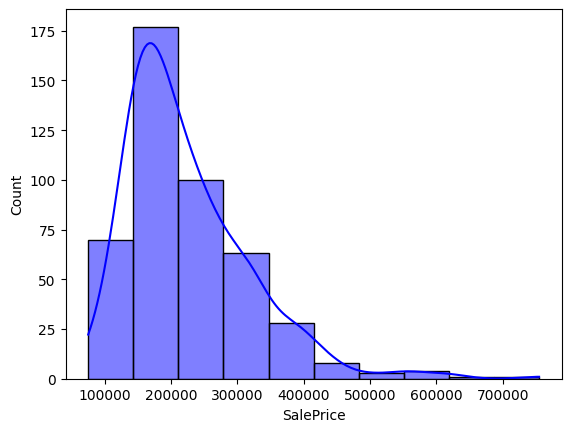

In [31]:
sns.histplot(df_train['SalePrice'], kde=True, bins=10, color='blue')

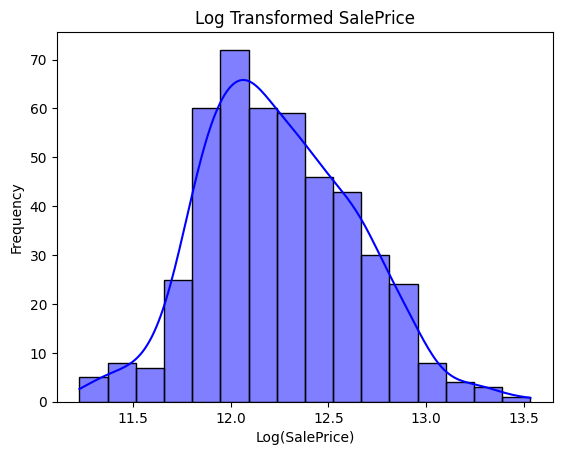

In [33]:
# Tambahkan kolom Log(SalePrice) ke dataset
df_train['SalePrice_Log'] = np.log(df_train['SalePrice'])

# Visualisasi histogram SalePrice setelah transformasi log
sns.histplot(df_train['SalePrice_Log'], kde=True, color='blue')
plt.title('Log Transformed SalePrice')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frequency')
plt.show()


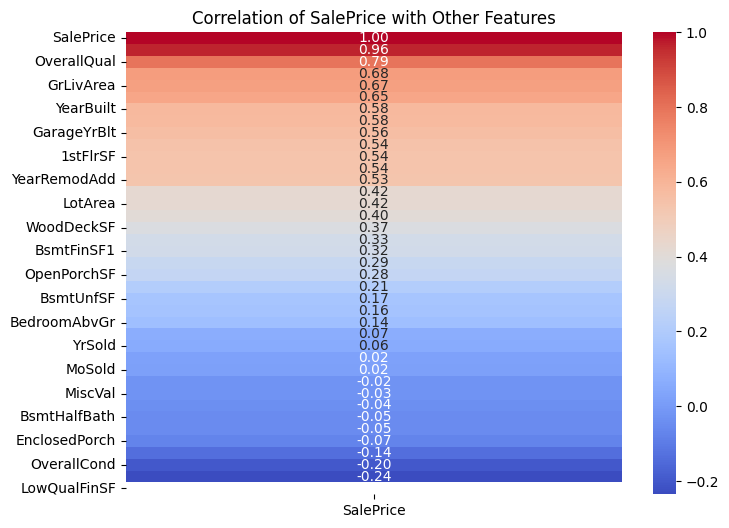

In [34]:
# Filter hanya kolom numerik
numeric_df = df_train.select_dtypes(include=['float64', 'int64'])

# Hitung matriks korelasi
corr_matrix = numeric_df.corr()

# Heatmap
# Correlation of SalePrice with other columns
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix[['SalePrice']].sort_values(by='SalePrice', ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('Correlation of SalePrice with Other Features')
plt.show()



In [35]:
corr_matrix["SalePrice"].sort_values(ascending=False).head(10)

,SalePrice
SalePrice,1.000000
SalePrice_Log,0.963793
OverallQual,0.794180
GarageCars,0.678345
GrLivArea,0.670844
GarageArea,0.648740
YearBuilt,0.584566
TotRmsAbvGrd,0.577539
GarageYrBlt,0.564661
FullBath,0.544830


<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

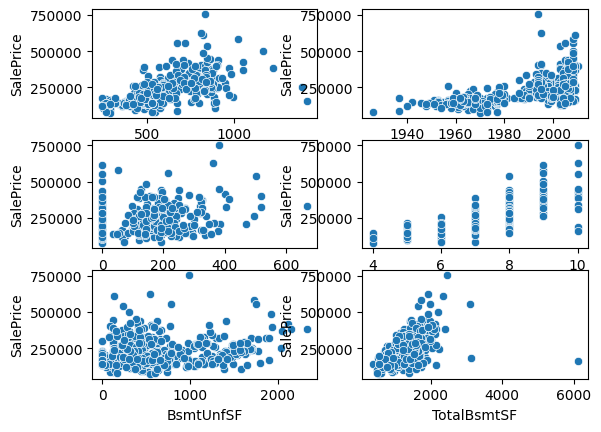

In [36]:
#GarageArea
plt.subplot(321)
sns.scatterplot(data=df_train, x='GarageArea', y="SalePrice")
#YearBuilt
plt.subplot(322)
sns.scatterplot(data=df_train, x='YearBuilt', y="SalePrice")
#WoodDeckSF
plt.subplot(323)
sns.scatterplot(data=df_train, x='WoodDeckSF', y="SalePrice")
#OverallQual
plt.subplot(324)
sns.scatterplot(data=df_train, x='OverallQual', y="SalePrice")
#BsmtUnfSF
plt.subplot(325)
sns.scatterplot(data=df_train, x='BsmtUnfSF', y="SalePrice")
#TotalBsmtSF
plt.subplot(326)
sns.scatterplot(data=df_train, x='TotalBsmtSF', y="SalePrice")

In [37]:
data = pd.concat([df_train,df_test], axis=0)
y_train = df_train['SalePrice']
data = data.drop(['Id', 'SalePrice'], axis=1)
print(data.shape)

(899, 75)


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 899 entries, 0 to 1458
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     899 non-null    int64  
 1   MSZoning       899 non-null    object 
 2   LotFrontage    899 non-null    float64
 3   LotArea        899 non-null    int64  
 4   Street         899 non-null    object 
 5   LotShape       899 non-null    object 
 6   LandContour    899 non-null    object 
 7   Utilities      899 non-null    object 
 8   LotConfig      899 non-null    object 
 9   LandSlope      899 non-null    object 
 10  Neighborhood   899 non-null    object 
 11  Condition1     899 non-null    object 
 12  Condition2     899 non-null    object 
 13  BldgType       899 non-null    object 
 14  HouseStyle     899 non-null    object 
 15  OverallQual    899 non-null    int64  
 16  OverallCond    899 non-null    int64  
 17  YearBuilt      899 non-null    int64  
 18  YearRemodAdd  

# Train-Test Split Dataset

In [39]:
train =data[:len(y_train)]
test = data[len(y_train):]
#Printing thier shapes
print(df_train.shape, df_test.shape)

(455, 77) (444, 75)


In [40]:
x_train, x_test, y_train, y_test = train_test_split(train, y_train, test_size=0.2, random_state=42)

# Modeling

## RANDOM FOREST

In [42]:
# Periksa tipe data pada dataset
print(x_train.dtypes)

# Pilih kolom non-numerik
categorical_columns = x_train.select_dtypes(include=['object']).columns
print("Kolom kategorikal:", categorical_columns)


MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice_Log    float64
Length: 75, dtype: object
Kolom kategorikal: Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')


In [43]:
# One-hot encode kolom kategorikal
x_train_encoded = pd.get_dummies(x_train, columns=categorical_columns, drop_first=True)
x_test_encoded = pd.get_dummies(x_test, columns=categorical_columns, drop_first=True)

# Pastikan kolom pada training dan test set sama
x_train_encoded, x_test_encoded = x_train_encoded.align(x_test_encoded, join='left', axis=1, fill_value=0)


In [44]:
# Training dengan data yang sudah diproses
rfr = RandomForestRegressor()
rfr.fit(x_train_encoded, y_train)

# Evaluasi menggunakan cross-validation
rfr_cv = cross_val_score(rfr, x_train_encoded, y_train, cv=5, scoring='r2')
print("R2:", rfr_cv.mean())


R2: 0.9881470005181534


In [45]:
# Random forest determined feature importances
rfr.feature_importances_

array([4.74402289e-06, 8.01521893e-05, 1.73472924e-04, 1.19645593e-05,
       3.17550603e-04, 1.95814786e-04, 1.06086765e-03, 6.46611298e-04,
       1.22911802e-04, 1.05429047e-05, 1.87293587e-04, 1.57971657e-03,
       6.69579199e-04, 2.94705000e-04, 0.00000000e+00, 6.39233598e-04,
       6.68986614e-05, 8.09707445e-04, 2.37215889e-05, 4.98456843e-05,
       9.45034190e-05, 1.49232994e-07, 4.02560122e-05, 7.65534288e-06,
       3.47769157e-04, 3.04367002e-06, 3.39991007e-05, 3.41021086e-04,
       3.96109711e-04, 1.18482595e-07, 6.43824727e-07, 1.51727294e-05,
       0.00000000e+00, 1.26555247e-08, 8.00087622e-04, 4.95126763e-05,
       9.87659021e-01, 0.00000000e+00, 5.76923645e-07, 4.10004097e-07,
       5.95219088e-10, 1.54249737e-06, 0.00000000e+00, 6.60589909e-05,
       5.03133979e-07, 2.58967346e-08, 4.53791510e-07, 1.76389846e-05,
       1.99294412e-07, 1.17989393e-07, 4.52561962e-06, 6.21916296e-08,
       0.00000000e+00, 1.55780883e-06, 0.00000000e+00, 0.00000000e+00,
      

# Plotting the Feature Importance

In [59]:
importance = rfr.feature_importances_

# map feature importance values to the features
feature_importances = zip(importance, X.columns)
#list(feature_importances)

sorted_feature_importances = sorted(feature_importances, reverse = True)
#print(sorted_feature_importances)

top_15_predictors = sorted_feature_importances[0:15]
values = [value for value, predictors in top_15_predictors]
predictors = [predictors for value, predictors in top_15_predictors]
print(predictors)

['BsmtUnfSF', 'Neighborhood', 'LotShape', 'OverallCond', 'BsmtFinType2', 'Condition1', 'LandContour', 'HouseStyle', 'Foundation', 'MasVnrType', 'ExterCond', 'LotArea', 'Condition2', 'Street', 'LandSlope']


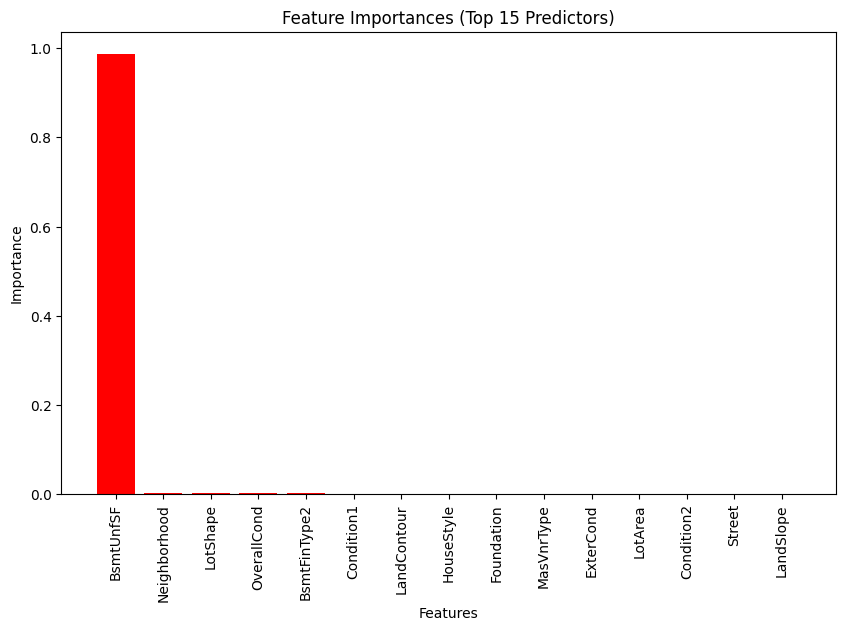

In [60]:
# Visualisasi feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(predictors)), values, color="r", align="center")
plt.xticks(range(len(predictors)), predictors, rotation=90)
plt.title("Feature Importances (Top 15 Predictors)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Variable Importance

Top 10 Features:
                Feature  Importance
36        SalePrice_Log    0.987659
11          TotalBsmtSF    0.001580
6          YearRemodAdd    0.001061
98  Exterior1st_HdBoard    0.000827
17         BsmtHalfBath    0.000810
34               MoSold    0.000800
12             1stFlrSF    0.000670
7            MasVnrArea    0.000647
15            GrLivArea    0.000639
95     RoofMatl_WdShngl    0.000528


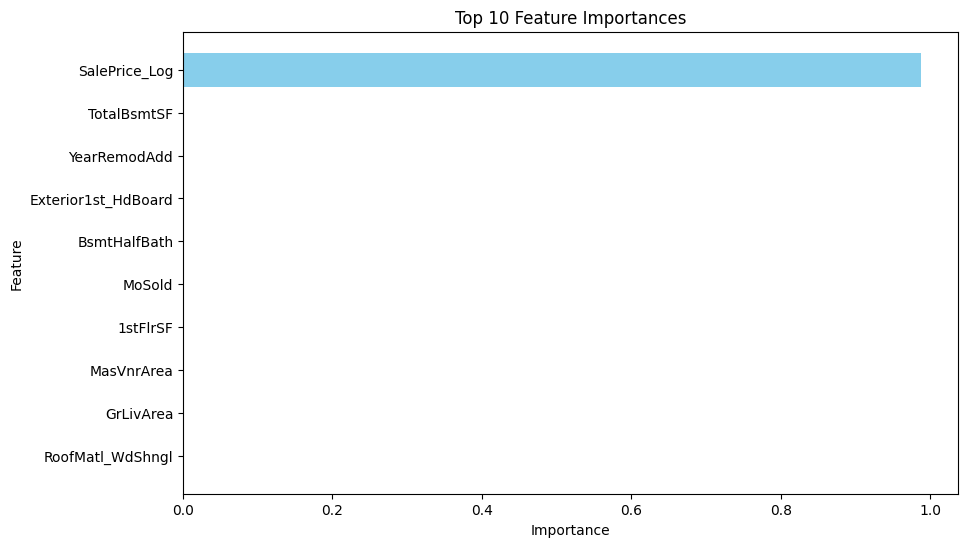

In [61]:
# Membuat DataFrame untuk feature importance
features_df = pd.DataFrame({
    'Feature': x_train_encoded.columns,  # Menggunakan kolom dari x_train_encoded
    'Importance': rfr.feature_importances_
})

# Urutkan berdasarkan importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Tampilkan 10 fitur teratas
print("Top 10 Features:")
print(features_df.head(10))

# Visualisasi 10 fitur teratas
top_10 = features_df.head(10).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_10["Feature"], top_10["Importance"], color='skyblue')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.show()


In [62]:
# Pastikan kolom x_test_encoded sama dengan x_train_encoded
x_test_encoded = x_test_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

# Prediksi pada data validasi
y_pred = rfr.predict(x_test_encoded)

# Evaluasi metrik
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Membuat DataFrame untuk hasil evaluasi
metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R^2'],
    'Value': [mse, rmse, mae, r2]
})

print("Metrics Evaluation:")
print(metrics_df)


Metrics Evaluation:
  Metric         Value
0    MSE  1.993847e+07
1   RMSE  4.465251e+03
2    MAE  1.352678e+03
3    R^2  9.971277e-01


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
